In [1]:
from cme.diffusion_models import diffusion as dd
import pandas as pd
import numpy as np
from cme.utils import common_utils as ut
import arviz as az
import os

In [2]:
from IPython.display import clear_output, DisplayHandle
def update_patch(self, obj):
    clear_output(wait=True)
    self.display(obj)
DisplayHandle.update = update_patch

In [3]:
import pymc
pymc.__version__

'5.3.0'

In [4]:
#from jax.lib import xla_bridge
#print(xla_bridge.get_backend().platform)

In [5]:
#rotation_RT = pd.read_csv(f"data/rotation_rt.csv")
#rotation_RT = pd.read_csv(f"data/sim_low_low_500_rt.csv")
rotation_RT = pd.read_csv(f"data/final_project_rt.csv")
rotation_RT_n = rotation_RT.loc[~rotation_RT.isna().any(axis=1),:].to_numpy()#[0:1,:]

#rotation_X = pd.read_csv(f"data/rotation_ra.csv")
#rotation_X = pd.read_csv(f"data/sim_low_low_500_ra.csv")
rotation_X = pd.read_csv(f"data/final_project_ra.csv")
rotation_X_n = rotation_X.loc[~rotation_RT.isna().any(axis=1),:].astype(int).to_numpy()#[0:1,:]

In [6]:
rotation_RT_n

array([[0.88 , 0.729, 2.   , 0.647, 1.23 , 1.665, 0.629, 1.882, 1.03 ,
        1.097, 0.613, 0.547, 0.796, 0.863, 0.413, 0.912, 0.613, 0.596,
        0.764, 0.647],
       [1.447, 2.   , 0.946, 0.847, 1.881, 0.812, 1.197, 0.729, 0.846,
        2.   , 1.598, 1.214, 1.983, 1.498, 1.014, 1.047, 0.68 , 0.646,
        1.431, 0.88 ],
       [1.147, 0.863, 1.565, 1.213, 1.564, 0.88 , 2.   , 0.813, 1.194,
        0.813, 1.331, 1.163, 1.147, 2.   , 0.913, 0.462, 1.064, 0.813,
        0.93 , 1.481],
       [1.097, 1.681, 1.214, 2.   , 1.063, 1.196, 0.947, 1.548, 1.665,
        1.13 , 1.248, 0.662, 0.645, 0.662, 1.415, 0.783, 0.528, 0.58 ,
        0.63 , 0.579],
       [0.796, 1.398, 1.347, 0.88 , 1.865, 0.781, 0.796, 0.796, 0.796,
        0.812, 1.598, 2.   , 2.   , 1.28 , 0.88 , 0.896, 1.849, 1.08 ,
        0.595, 0.613],
       [2.   , 2.   , 2.   , 2.   , 2.   , 2.   , 2.   , 2.   , 2.   ,
        2.   , 0.846, 2.   , 2.   , 2.   , 2.   , 2.   , 2.   , 2.   ,
        2.   , 2.   ],
       [2.

In [7]:
rotation_RT_n[rotation_RT_n < 0.9]

array([0.88 , 0.729, 0.647, 0.629, 0.613, 0.547, 0.796, 0.863, 0.413,
       0.613, 0.596, 0.764, 0.647, 0.847, 0.812, 0.729, 0.846, 0.68 ,
       0.646, 0.88 , 0.863, 0.88 , 0.813, 0.813, 0.462, 0.813, 0.662,
       0.645, 0.662, 0.783, 0.528, 0.58 , 0.63 , 0.579, 0.796, 0.88 ,
       0.781, 0.796, 0.796, 0.796, 0.812, 0.88 , 0.896, 0.595, 0.613,
       0.846, 0.778, 0.847, 0.662, 0.813, 0.713, 0.747, 0.812, 0.863,
       0.647, 0.815, 0.712, 0.646, 0.528, 0.796, 0.413, 0.678, 0.497,
       0.83 , 0.714, 0.579, 0.681, 0.613, 0.68 , 0.764, 0.863, 0.713,
       0.563, 0.528, 0.746, 0.562, 0.545, 0.579, 0.379, 0.562, 0.83 ,
       0.763, 0.78 , 0.68 , 0.763, 0.312, 0.896, 0.395, 0.211, 0.395,
       0.411, 0.829, 0.48 , 0.462, 0.261, 0.312, 0.378, 0.479, 0.229,
       0.362, 0.346, 0.462, 0.879, 0.379, 0.613, 0.847, 0.428, 0.645,
       0.379, 0.629, 0.312, 0.144, 0.478, 0.446, 0.713, 0.864, 0.296,
       0.446, 0.278])

In [8]:
samples_n, tune, chains, acceptance_rate = 700, 300, 4, 0.99

posterior_chain,_ = dd.sample_posterior_params(rotation_RT_n, rotation_X_n, 
samples_n,chains=chains, sampler="MH", tune=tune, acceptance_rate = acceptance_rate)


In [9]:
posterior_chain

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [10]:
az.summary(posterior_chain)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m[0],0.153,1.074,-2.010,2.061,0.058,0.041,342.0,492.0,1.01
m[1],0.921,0.378,0.378,1.625,0.032,0.023,131.0,168.0,1.05
m[2],-0.011,1.057,-2.038,1.934,0.067,0.048,247.0,406.0,1.02
m[3],-0.030,1.046,-1.889,1.995,0.079,0.056,181.0,269.0,1.02
s[0],-0.001,0.215,-0.398,0.425,0.010,0.009,477.0,504.0,1.01
...,...,...,...,...,...,...,...,...,...
"t_er[9, 0]",0.494,0.218,0.117,0.883,0.015,0.011,192.0,279.0,1.02
"t_er[10, 0]",0.494,0.215,0.124,0.884,0.015,0.011,192.0,241.0,1.02
"t_er[11, 0]",0.494,0.219,0.119,0.887,0.016,0.011,187.0,285.0,1.03
"t_er[12, 0]",0.496,0.215,0.136,0.894,0.015,0.011,200.0,284.0,1.03


In [11]:
df_posterior_chain = ut.get_summary(posterior_chain)
df_posterior_chain

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,var_name,var_idx
0,0.153,1.074,-2.010,2.061,0.058,0.041,342.0,492.0,1.01,m,0]
1,0.921,0.378,0.378,1.625,0.032,0.023,131.0,168.0,1.05,m,1]
2,-0.011,1.057,-2.038,1.934,0.067,0.048,247.0,406.0,1.02,m,2]
3,-0.030,1.046,-1.889,1.995,0.079,0.056,181.0,269.0,1.02,m,3]
4,-0.001,0.215,-0.398,0.425,0.010,0.009,477.0,504.0,1.01,s,0]
...,...,...,...,...,...,...,...,...,...,...,...
115,0.494,0.218,0.117,0.883,0.015,0.011,192.0,279.0,1.02,t_er,"9, 0]"
116,0.494,0.215,0.124,0.884,0.015,0.011,192.0,241.0,1.02,t_er,"10, 0]"
117,0.494,0.219,0.119,0.887,0.016,0.011,187.0,285.0,1.03,t_er,"11, 0]"
118,0.496,0.215,0.136,0.894,0.015,0.011,200.0,284.0,1.03,t_er,"12, 0]"


In [12]:
r_hat = ut.get_rhat(df_posterior_chain)
r_hat

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
r_hat,1.01,1.05,1.02,1.02,1.01,1.05,1.02,1.02,1.0,1.01,...,1.03,1.02,1.03,1.02,1.02,1.02,1.02,1.03,1.03,1.02


array([[<AxesSubplot:title={'center':'m'}>,
        <AxesSubplot:title={'center':'m'}>],
       [<AxesSubplot:title={'center':'s'}>,
        <AxesSubplot:title={'center':'s'}>],
       [<AxesSubplot:title={'center':'v_pr'}>,
        <AxesSubplot:title={'center':'v_pr'}>],
       [<AxesSubplot:title={'center':'a_pr'}>,
        <AxesSubplot:title={'center':'a_pr'}>],
       [<AxesSubplot:title={'center':'z_pr'}>,
        <AxesSubplot:title={'center':'z_pr'}>],
       [<AxesSubplot:title={'center':'t_er_pr'}>,
        <AxesSubplot:title={'center':'t_er_pr'}>],
       [<AxesSubplot:title={'center':'v'}>,
        <AxesSubplot:title={'center':'v'}>],
       [<AxesSubplot:title={'center':'a'}>,
        <AxesSubplot:title={'center':'a'}>],
       [<AxesSubplot:title={'center':'z'}>,
        <AxesSubplot:title={'center':'z'}>],
       [<AxesSubplot:title={'center':'t_er'}>,
        <AxesSubplot:title={'center':'t_er'}>]], dtype=object)

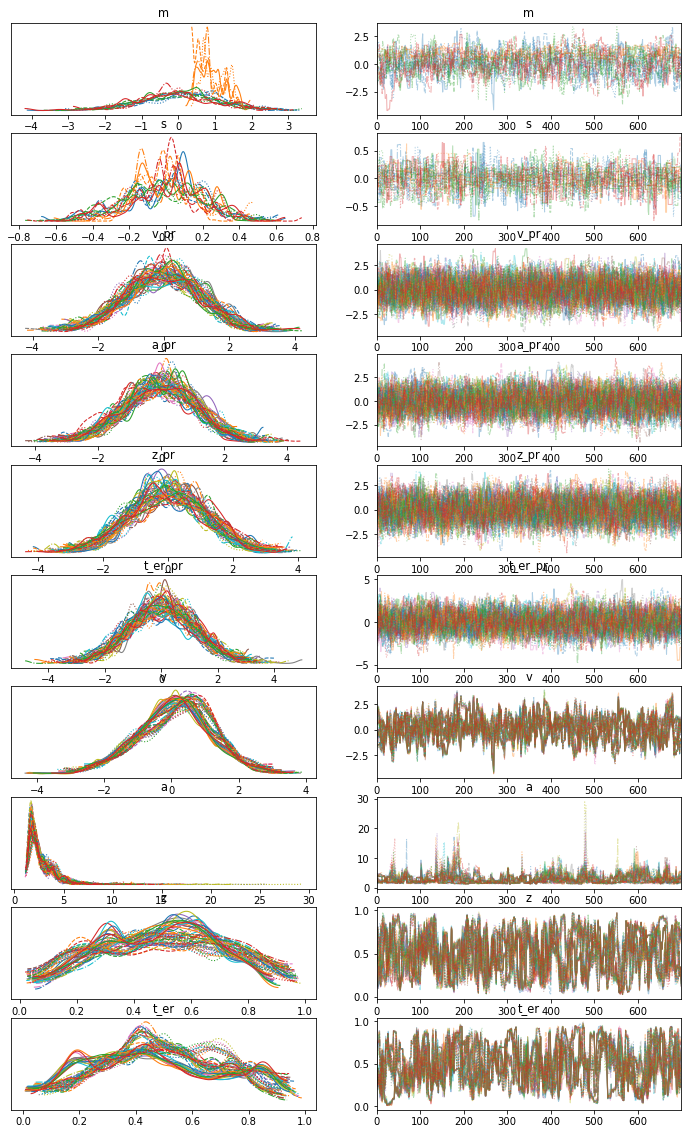

In [13]:
az.plot_trace(posterior_chain)

In [14]:
#posterior_chain = posterior_chain.sel(chain=[0,2,3])

In [15]:
az.summary(posterior_chain)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m[0],0.153,1.074,-2.010,2.061,0.058,0.041,342.0,492.0,1.01
m[1],0.921,0.378,0.378,1.625,0.032,0.023,131.0,168.0,1.05
m[2],-0.011,1.057,-2.038,1.934,0.067,0.048,247.0,406.0,1.02
m[3],-0.030,1.046,-1.889,1.995,0.079,0.056,181.0,269.0,1.02
s[0],-0.001,0.215,-0.398,0.425,0.010,0.009,477.0,504.0,1.01
...,...,...,...,...,...,...,...,...,...
"t_er[9, 0]",0.494,0.218,0.117,0.883,0.015,0.011,192.0,279.0,1.02
"t_er[10, 0]",0.494,0.215,0.124,0.884,0.015,0.011,192.0,241.0,1.02
"t_er[11, 0]",0.494,0.219,0.119,0.887,0.016,0.011,187.0,285.0,1.03
"t_er[12, 0]",0.496,0.215,0.136,0.894,0.015,0.011,200.0,284.0,1.03


<AxesSubplot:ylabel='Density'>

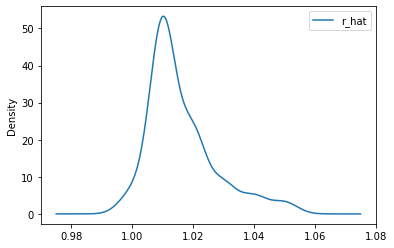

In [16]:
r_hat.T.plot(kind="kde")

In [17]:
#az.plot_trace(posterior_chain)

In [26]:
v_c_ch = ut.get_chains_for_param(posterior_chain,"v")
v_c_ch

,0,1,2,3
0,-0.143617,-1.680132,0.586835,1.671508
1,0.201110,-1.667657,0.838620,1.431437
2,-0.421551,-1.660994,0.914686,1.208121
3,-0.848776,-1.658819,0.827565,1.816606
4,-0.814297,-1.637131,0.561955,1.301631
...,...,...,...,...
9795,0.624401,-0.115259,-1.383713,0.023344
9796,0.639593,-0.192309,-1.454954,0.436844
9797,0.550060,0.083072,-0.834392,0.187813
9798,0.592548,-0.167707,-0.804718,0.084028


<AxesSubplot:ylabel='Density'>

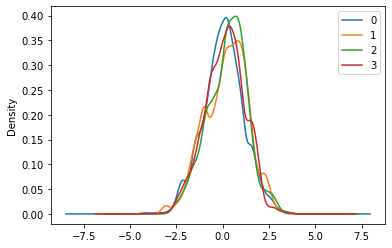

In [27]:
v_c_ch.plot(kind="kde")

In [28]:
a_c_ch = ut.get_chains_for_param(posterior_chain,"a")
a_c_ch

,0,1,2,3
0,1.412081,4.537320,2.012169,1.936358
1,2.026360,3.852747,2.092441,2.149502
2,1.872939,4.601077,2.288091,2.491338
3,1.319716,4.543275,2.059360,2.013803
4,1.356576,4.635809,2.112595,2.119026
...,...,...,...,...
9795,4.635072,2.471388,1.897954,2.255591
9796,3.044976,2.250816,3.013622,1.953979
9797,5.573477,3.010011,3.611428,1.979954
9798,3.981747,2.583897,3.179383,2.314262


<AxesSubplot:ylabel='Density'>

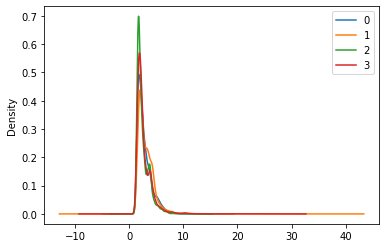

In [29]:
a_c_ch.fillna(0).plot(kind="kde")

In [30]:
z_c_ch = ut.get_chains_for_param(posterior_chain,"z")
z_c_ch

,0,1,2,3
0,0.140545,0.354651,0.452738,0.566950
1,0.177212,0.349071,0.433236,0.535990
2,0.142556,0.372535,0.436939,0.560034
3,0.085022,0.353365,0.436632,0.586117
4,0.128168,0.327985,0.467279,0.568387
...,...,...,...,...
9795,0.123859,0.775239,0.682174,0.348343
9796,0.202507,0.767717,0.762058,0.348035
9797,0.204866,0.779094,0.670599,0.348346
9798,0.153724,0.778293,0.655269,0.347874


<AxesSubplot:ylabel='Density'>

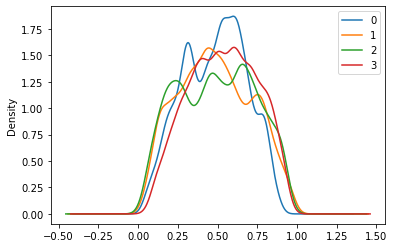

In [31]:
z_c_ch.fillna(0).plot(kind="kde")

In [32]:
ter_c_ch = ut.get_chains_for_param(posterior_chain,"t_er")
ter_c_ch

,0,1,2,3
0,0.708750,0.323935,0.433021,0.434780
1,0.695637,0.285008,0.431060,0.417167
2,0.591364,0.240913,0.436222,0.385183
3,0.691414,0.383479,0.447311,0.415778
4,0.641847,0.323180,0.430812,0.425005
...,...,...,...,...
9795,0.748208,0.258686,0.324209,0.308536
9796,0.563322,0.249439,0.275385,0.312054
9797,0.510165,0.248868,0.782258,0.310514
9798,0.640938,0.249505,0.204340,0.317810


<AxesSubplot:ylabel='Density'>

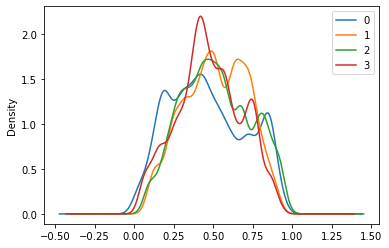

In [33]:
ter_c_ch.fillna(0).plot(kind="kde")